# Strong and weak Z2 indices in three dimensions
In three dimensions a time-reversal-symmetric insulator has four $Z_2$ invariants, which
`h.get_topological_invariant()` returns. Let us take a plane of the Brillouin zone at a fixed
momentum $k_i$ along one reciprocal lattice vector. At $k_i=0$ and at $k_i=1/2$ time reversal maps
the plane onto itself, so each of these six planes is a two-dimensional time-reversal-symmetric
insulator with a $Z_2$ invariant of its own, computed from the flow of its hybrid Wannier centers.
Four combinations of them are independent, written $\nu_0;(\nu_1\nu_2\nu_3)$: the weak index
$\nu_i$ is the invariant of the plane $k_i=1/2$, and the strong index $\nu_0$ is the product of the
invariants of the planes $k_i=0$ and $k_i=1/2$. You can think of a weak topological insulator,
$\nu_0=0$ with some $\nu_i=1$, as quantum spin Hall layers stacked along
$\nu_1\vec b_1+\nu_2\vec b_2+\nu_3\vec b_3$, with Dirac cones only on the surfaces that cut the
layers, while a strong one, $\nu_0=1$, has an odd number of Dirac cones on every surface, which is
what ARPES sees. When time reversal is broken, the same call returns the Chern vector
$(C_1,C_2,C_3)$ instead, the Chern numbers of the planes at fixed $k_1$, $k_2$ and $k_3$.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import topology


### The three phases of the Fu-Kane-Mele model
We take the diamond lattice with spin-orbit coupling between second neighbors, where the gap opens
once one of the four first-neighbor bonds differs from the other three, and rescale the bond inside
the unit cell. A weaker bond gives a weak topological insulator $0;(111)$, a stronger one a strong
topological insulator $1;(111)$, and a bond beyond $3t$ a band insulator of decoupled dimers
$0;(000)$. The map shows the four indices, one row each, as the bond grows; the gap closes at a bond
of $t$ and of $3t$, which is where the indices change.

bond = 0.5 t   Z2 indices = 0;(111)


bond = 0.7 t   Z2 indices = 0;(111)


bond = 0.9 t   Z2 indices = 0;(111)


bond = 1.1 t   Z2 indices = 1;(111)


bond = 1.3 t   Z2 indices = 1;(111)


bond = 1.7 t   Z2 indices = 1;(111)


bond = 2.0 t   Z2 indices = 1;(111)


bond = 2.5 t   Z2 indices = 1;(111)


bond = 3.5 t   Z2 indices = 0;(000)


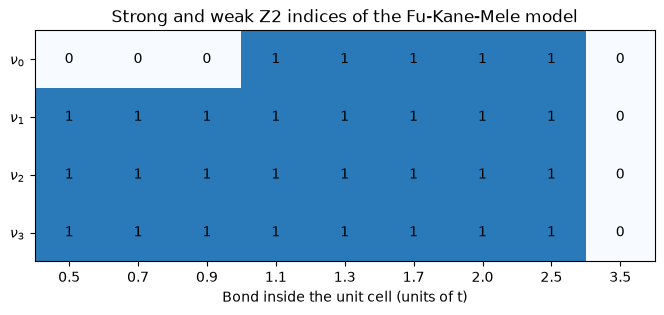

In [2]:
g = geometry.diamond_lattice_minimal() # diamond lattice, two sites per cell
scales = [0.5,0.7,0.9,1.1,1.3,1.7,2.0,2.5,3.5] # hopping of that bond, in units of t
Z = np.zeros((4,len(scales)))
for (j,s) in enumerate(scales):
    h = g.get_hamiltonian() # first-neighbor hopping
    h.add_kane_mele(0.05) # spin-orbit coupling between second neighbors
    h.intra = s*h.intra # rescale the bond inside the unit cell
    (nu0,nus) = h.get_topological_invariant(nk=30,nt=30) # strong and weak Z2 indices
    Z[:,j] = [nu0]+list(nus)
    print("bond =",s,"t   Z2 indices =",str(nu0)+";("+"".join(map(str,nus))+")")

plt.figure(figsize=(8,3))
plt.imshow(Z,cmap="Blues",vmin=0,vmax=1.4,aspect="auto")
for i in range(4):
    for j in range(len(scales)): plt.text(j,i,int(Z[i,j]),ha="center",va="center")
plt.yticks(range(4),["$\\nu_0$","$\\nu_1$","$\\nu_2$","$\\nu_3$"])
plt.xticks(range(len(scales)),scales) ; plt.xlabel("Bond inside the unit cell (units of t)")
plt.title("Strong and weak Z2 indices of the Fu-Kane-Mele model")
plt.show()


### The Chern vector of stacked Chern insulators
Without time reversal the same call returns the Chern vector. We stack spinless Haldane layers
along $\vec a_3$ with a weak vertical hopping, and the Chern vector is $(0,0,C)$, with $C$ the
Chern number of one layer, meaning a Hall conductance $C e^2/h$ per layer.

In [3]:
g = geometry.honeycomb_lattice() # one Haldane layer
g.a3 = np.array([0.,0.,2.]) # stack the layers along z
g.dimensionality = 3
def fun(r1,r2): # hopping 1 inside a layer, 0.1 between layers
    dr = r1-r2
    if abs(dr[2])<1e-4 and abs(np.linalg.norm(dr)-1.)<1e-4: return 1.0
    if abs(abs(dr[2])-2.)<1e-4 and np.linalg.norm(dr[:2])<1e-4: return 0.1
    return 0.0
h = g.get_hamiltonian(fun=fun,has_spin=False) # stacked layers
h.add_haldane(0.1) # Haldane coupling in each layer
print("Chern vector =",h.get_topological_invariant(nk=20,nt=40))


Chern vector = (0, 0, 1)
